# 23e — Fisher uncertainties for the exp6 `trial_07` model on the 14 real experiments

**23e — 23b's model with ONE change: the μ step is calibrated PER EXPERIMENT.** 23b is the best model for the
high-T purpose, but it uses a **single global** `LR_MU_Z` (calibrated so the *median* cell takes a 3.3-photon
step), which leaves the high-`σ_prop` cells (3nW T40–T100) **step-starved** — they covered only 21–73 % of the
required travel. Here the same 3.3-photon target is applied **to each experiment individually**
(`LR_e = TARGET_STEP / |∇μ_z at init|_e`), which is exactly a `LR ∝ σ_prop²` correction. Everything else is
frozen: reward, score denominator, kernel, σ channel, γ channel and protocol.

The rest of the model is the **22a mechanism**: the series-21/17g model with the **z-scored** per-run
log-likelihood reward (`loglik_z`, `sigma_prop` score denominator), **plain Scott bandwidths**,
**full σ channel**, **no γ trust region**, **no clip and no clamps**, `LR_GAMMA = 0.5`.
Init `0.5 x truth`, `n_runs = 100`, `n_iter = 30`.
**Everything else — the 14 real experiments, the Fisher/CRB analysis, the two variants, the figures and the
layout — is identical to 23a**, so the two notebooks differ only in the model.

**Why KDE.** Fisher/Cramér-Rao needs a likelihood. The 2-D `(FWHM, sigma_fit)` **KDE** is our likelihood;
the exp8 alternative losses (Wasserstein, CvM, energy, MMD) are discrepancies and have no CRB. So the
KDE-only model is the right base for an uncertainty analysis.

**What this notebook does.** For **all 14 real experiments**:
1. runs the frozen optimisation (deterministic), records the full path + per-step simulated cloud;
2. at the optimum computes the **Fisher information of the KDE likelihood** and the CRB uncertainties
   `sigma_mu`, `sigma_gamma` (and their correlation) under the **existing convention** (the per-scan
   normalisation `J = sum_i s_i s_i^T / N`) **and** the dataset correction:
   - **A — per-scan**: the historic convention (the uncertainty of a *single* scan);
   - **B — dataset**: `sigma_data = sigma_single / sqrt(n_target)` — the CRB for the estimate from the
     whole experiment (undo the `/N`).

**Not touched.** No change to `src/` or to any previous notebook; this notebook copies the exp6 helpers
it needs. Figures render **inline only** (no savefig); executed **in place**.

## Panel (series-22 visual conventions)
- **FIG 1 (interactive, Plotly)** — per experiment: the **(mu, gamma) parameter path** (left) and the
  **generated (FWHM, sigma_fit) cloud at that step** (right) against the real data. Experiment dropdown +
  play button / slider over the iteration.
- **FIG 2 — the uncertainty report: μ on top, γ underneath** (one panel each, `hat/true` vs transmission
  with the CRB whiskers); the **hue is the laser power** (1nW | 3nW).
- **FIG 3** normalised trajectories `mu/mu_true`, `gamma/gamma_true` vs iteration (per power).
- **FIG 4** accuracy vs transmission (mu and gamma ratios, both powers, goal bands).

In [1]:
# ============================================================
# 23e — imports (repo bootstrap like the 22-series)
# ============================================================
import math, os, sys, time, json
from contextlib import nullcontext
import numpy as np
import torch
import multiprocessing as _mp
from concurrent.futures import ProcessPoolExecutor as _PPE

torch.set_default_dtype(torch.float32)
for _p in [os.getcwd(), os.path.join(os.getcwd(), '..'), os.path.join(os.getcwd(), '..', '..')]:
    if os.path.isdir(os.path.join(_p, 'src')):
        sys.path.insert(0, _p); REPO_ROOT = _p; break
os.chdir(REPO_ROOT)

from src.fitting import fit_profile, fwhm_from_theta, nll
from src.samplers import draw_fixed_noise
from src.implicit import compute_fwhm_and_dgamma

import plotly
import plotly.graph_objects as go
import plotly.io as pio
from plotly.subplots import make_subplots
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter
pio.templates.default = 'plotly_white'
pio.renderers.default = os.environ.get('PLOTLY_RENDERER', 'vscode')
print('Imports OK | plotly', plotly.__version__, '| repo', REPO_ROOT)


Imports OK | plotly 7.1.0 | repo /home/pukky/.openclaw/workspace/qm-ml


In [2]:
# ============================================================
# 23e — EXPERIMENTS (14 real; true values from Gregor's fits)
# ============================================================
EXPERIMENTS = [
    dict(name='1nW Trans05',  power='1nW', mu_true=9.393,   sigma_prop=2.576,  lam=2.232, gamma_true=8.5,  n_target=61),
    dict(name='1nW Trans10',  power='1nW', mu_true=12.372,  sigma_prop=3.445,  lam=2.122, gamma_true=8.5,  n_target=358),
    dict(name='1nW Trans20',  power='1nW', mu_true=17.316,  sigma_prop=4.141,  lam=2.286, gamma_true=8.5,  n_target=1138),
    dict(name='1nW Trans40',  power='1nW', mu_true=38.405,  sigma_prop=7.198,  lam=2.351, gamma_true=8.5,  n_target=2428),
    dict(name='1nW Trans60',  power='1nW', mu_true=61.374,  sigma_prop=9.851,  lam=2.593, gamma_true=8.5,  n_target=2424),
    dict(name='1nW Trans80',  power='1nW', mu_true=79.365,  sigma_prop=12.627, lam=2.758, gamma_true=8.5,  n_target=2487),
    dict(name='1nW Trans100', power='1nW', mu_true=70.817,  sigma_prop=17.221, lam=2.636, gamma_true=8.5,  n_target=2455),
    dict(name='3nW Trans05',  power='3nW', mu_true=13.204,  sigma_prop=3.724,  lam=2.186, gamma_true=14.1, n_target=252),
    dict(name='3nW Trans10',  power='3nW', mu_true=24.476,  sigma_prop=5.639,  lam=2.158, gamma_true=14.1, n_target=1572),
    dict(name='3nW Trans20',  power='3nW', mu_true=34.279,  sigma_prop=8.319,  lam=2.264, gamma_true=14.1, n_target=2171),
    dict(name='3nW Trans40',  power='3nW', mu_true=84.892,  sigma_prop=24.013, lam=2.475, gamma_true=14.1, n_target=3742),
    dict(name='3nW Trans60',  power='3nW', mu_true=103.203, sigma_prop=23.95,  lam=2.741, gamma_true=14.1, n_target=2541),
    dict(name='3nW Trans80',  power='3nW', mu_true=137.537, sigma_prop=32.107, lam=2.911, gamma_true=14.1, n_target=2508),
    dict(name='3nW Trans100', power='3nW', mu_true=175.707, sigma_prop=40.975, lam=3.087, gamma_true=14.1, n_target=2516),
]
POWERS = ['1nW', '3nW']
TRANS  = ['05', '10', '20', '40', '60', '80', '100']
print(len(EXPERIMENTS), 'experiments')


14 experiments


In [3]:
# ============================================================
# 23a CONFIG — FROZEN experiment_6 trial_07 model + the Fisher knobs
# ============================================================
CFG = dict(
    n_runs=100, n_iter=30,                       # series-21 / 22a protocol
    lr_gamma=0.5,                                # 21i/22a: unchanged (raw |grad_gamma| ~ O(1))
    gamma_anneal=0.5,                            # 22a: gamma decay fixed at 0.5
    sigma_ref=10.0,                              # kept for reference (score uses sigma_prop)
    clip=float('inf'),                           # NO gradient clipping (21i)
    # --- 22a model: Scott bandwidths, full sigma channel, no gamma trust region ---
    h_f_scale=1.0, h_s_scale=1.0, h_s_min=0.05,
    sigma_weight=1.0,                            # no sigma-channel damping
    gamma_rel_cap=0.0,                           # no gamma trust region
    reward_mode='loglik_z',                      # 22a: z-scored per-run log-likelihood
    mu_guard=1500.0, gamma_guard=(0.02, 500.0),  # divergence STOP bands
    # ---- THE 23e CHANGE (one knob vs 23b) -----------------------------------------
    #   'global'         = 23b: ONE LR_MU_Z for all 14 (calibrated on the MEDIAN cell)
    #   'per_experiment' = THIS notebook: LR_e = TARGET_STEP / |grad_mu_z at init|_e
    #                      -> every cell targets the same 3.3-photon step (LR ~ sigma_prop^2)
    step_calibration='per_experiment',
)
TARGET_STEP = 3.3                                # 22a: match the z-arm median step to 21i's 3.3 photons/iter
N_WORKERS = 4
H_REF = 1.0            # z-form gamma-score reference (optimizer only)
SEED  = 42             # per-step noise seed base (deterministic)
REAL_CSV = os.path.join(REPO_ROOT, 'data', 'processed', 'fwhm_linewidths.csv')

# ---- Fisher knobs ----
M_FINAL          = 500     # simulated scans for the Fisher estimate (per seed)
FISHER_SEEDS     = 5       # independent seeds averaged (as 12d)
FISHER_BASE_SEED = 7000

OUT_JSON = os.path.join(REPO_ROOT, 'data', 'processed', '23e_fisher_22a_perexp.json')

SMOKE = os.environ.get('NB_SMOKE') == '1'
if SMOKE:
    CFG['n_runs'], CFG['n_iter'] = 20, 4
    EXPERIMENTS = EXPERIMENTS[4:5]
    M_FINAL, FISHER_SEEDS = 40, 1
CACHED = (not SMOKE) and os.path.exists(OUT_JSON) and os.environ.get('NB_RECOMPUTE') != '1'
print('config: %s | M_FINAL=%d, seeds=%d | SMOKE=%s | CACHED=%s' % (CFG, M_FINAL, FISHER_SEEDS, SMOKE, CACHED))


config: {'n_runs': 100, 'n_iter': 30, 'lr_gamma': 0.5, 'gamma_anneal': 0.5, 'sigma_ref': 10.0, 'clip': inf, 'h_f_scale': 1.0, 'h_s_scale': 1.0, 'h_s_min': 0.05, 'sigma_weight': 1.0, 'gamma_rel_cap': 0.0, 'reward_mode': 'loglik_z', 'mu_guard': 1500.0, 'gamma_guard': (0.02, 500.0), 'step_calibration': 'per_experiment'} | M_FINAL=500, seeds=5 | SMOKE=False | CACHED=False


In [4]:
# ============================================================
# 23e — helpers (verbatim from experiment_6/ag_hypopt.py, plus a gamma_scale switch)
# ============================================================
GAMMA_SCALE = True     # optimizer uses the z-form gamma-score; the Fisher sets this False

def _kde_scores(sim_f, sim_s, sim_n, sim_df, sim_ds, data_f, data_s, h_f, h_s, mu, sigma_prop, cfg):
    '''2-D KDE log-likelihood pieces + per-DATA-POINT scores (as exp5/6).'''
    sw = float(cfg.get('sigma_weight', 1.0))
    d_f = data_f[:, None] - sim_f[None, :]
    d_s = data_s[:, None] - sim_s[None, :]
    W = torch.exp(-0.5 * (d_f / h_f) ** 2 - 0.5 * sw * (d_s / h_s) ** 2)
    w = W / W.sum(dim=1, keepdim=True).clamp_min(1e-12)
    score = (sim_n[None, :] - mu) / sigma_prop ** 2
    s_mu = (w * score).sum(dim=1)
    if GAMMA_SCALE:
        dlogG = ((d_f * sim_df[None, :]) / h_f + sw * (d_s * sim_ds[None, :]) / h_s) / H_REF
    else:
        dlogG = (d_f * sim_df[None, :]) / h_f ** 2 + sw * (d_s * sim_ds[None, :]) / h_s ** 2
    s_gamma = (w * dlogG).sum(dim=1)
    logp = torch.log((W.sum(dim=1) / len(sim_f)).clamp_min(1e-30))
    return s_mu, s_gamma, -logp.mean(), w, W

def reward_vector(mode, W):
    '''22a reward = Anuar's per-run Gaussian log-likelihood of the real data (SUM over data points),
    Z-SCORED across the N_RUNS draws (scale-free: direction only; acts as a per-step adaptive LR).'''
    r = torch.log(W.clamp_min(1e-30)).sum(dim=0)
    if mode == 'loglik_sum':
        return r
    if mode == 'loglik_z':
        return (r - r.mean()) / (r.std() + 1e-12)
    raise ValueError(mode)

def _fit_fn(ph):  return fit_profile(ph, n_iters=80, model='lorentzian', uniform_bg=False)
def _fwhm_fn(th): return fwhm_from_theta(th, model='lorentzian')
def _nll_fn(th, ph): return nll(th, ph, model='lorentzian', uniform_bg=False)

def _run_one(args):
    gamma_val, u, b = args
    return compute_fwhm_and_dgamma(gamma_val, u, b, _fit_fn, _fwhm_fn, _nll_fn, n_params=2)

def _init_worker(): torch.set_num_threads(1)
def _parallel_map(pool, tasks): return list(pool.map(_run_one, tasks, chunksize=8))

def _load_real_target(exp):
    '''Real measured target for `exp` (15-series convention): raw*1000 -> MHz, keep err/fwhm < 10.'''
    import pandas as pd
    power_nW = int(str(exp['power']).replace('nW', ''))
    trans = int(str(exp['name']).split('Trans')[-1])
    df = pd.read_csv(REAL_CSV)
    sub = df[(df['power_nW'] == power_nW) & (df['transmission'] == trans)]
    f = sub['fwhm'].to_numpy(dtype=float) * 1000.0
    e = sub['fit_error'].to_numpy(dtype=float) * 1000.0
    with np.errstate(invalid='ignore', divide='ignore'):
        ok = np.isfinite(f) & np.isfinite(e) & (f > 0)
        filt = ok & ((e / f) < 10.0)
    return (torch.tensor(f[filt], dtype=torch.float32), torch.tensor(e[filt], dtype=torch.float32))

def _bandwidths(target_f, target_s, h_f_scale, h_s_scale, h_s_min):
    '''Scott-from-target, scaled (FIXED w.r.t. mu,gamma -> a clean likelihood).'''
    scott = len(target_f) ** (-1.0 / 6.0)
    H_F = h_f_scale * float(target_f.std()) * scott
    H_S = max(h_s_scale * float(target_s.std()) * scott, h_s_min)
    return H_F, H_S

def _sims(pool, mu, sigma_prop, lam, gamma, n_runs, seed):
    rng = np.random.default_rng(seed)
    tasks, ns = [], []
    for _ in range(n_runs):
        u, b, n = draw_fixed_noise(mu, sigma_prop, lam, rng)
        tasks.append((gamma, u.numpy(), b.numpy())); ns.append(n)
    res = _parallel_map(pool, tasks)
    return (torch.tensor([r[0] for r in res], dtype=torch.float32),
            torch.tensor([r[1] for r in res], dtype=torch.float32),
            torch.tensor(ns, dtype=torch.float32),
            torch.tensor([r[2] for r in res], dtype=torch.float32),
            torch.tensor([r[3] for r in res], dtype=torch.float32))

def _fisher_at(pool, mu, gamma, sigma_prop, lam, target_f, target_s, H_F, H_S, cfg):
    '''Fisher of the KDE likelihood at (mu,gamma): per-scan J and the data-scaled J.
       Returns dict with sigma_mu/sigma_gamma under the per-scan normalisation and the
       dataset correction sigma/sqrt(N).'''
    global GAMMA_SCALE
    gs = GAMMA_SCALE; GAMMA_SCALE = False          # Fisher uses the RAW likelihood chain
    N = int(len(target_f))
    Js = []
    try:
        for s_i in range(FISHER_SEEDS):
            ft, si_t, nt, dg_t, ds_t = _sims(pool, mu, sigma_prop, lam, gamma, M_FINAL, FISHER_BASE_SEED + s_i)
            s_mu, s_gamma, _, _, _ = _kde_scores(ft, si_t, nt, dg_t, ds_t,
                                                 target_f, target_s, H_F, H_S, mu, sigma_prop, cfg)
            s = torch.stack([s_mu, s_gamma], dim=1)
            Js.append(s.T @ s / N)                 # the EXISTING convention (per-scan)
    finally:
        GAMMA_SCALE = gs
    J_single = torch.stack(Js).mean(dim=0)
    inv_single = torch.linalg.inv(J_single + 1e-12 * torch.eye(2))
    inv_data = inv_single / N                      # dataset CRB = (N*J)^-1
    out = dict(N=N, J=J_single.tolist(),
               sig_mu_single=float(math.sqrt(inv_single[0, 0])),
               sig_g_single=float(math.sqrt(inv_single[1, 1])),
               corr_single=float(inv_single[0, 1] / math.sqrt(inv_single[0, 0] * inv_single[1, 1])),
               sig_mu_data=float(math.sqrt(inv_data[0, 0])),
               sig_g_data=float(math.sqrt(inv_data[1, 1])),
               corr_data=float(inv_data[0, 1] / math.sqrt(inv_data[0, 0] * inv_data[1, 1])))
    return out

print('helpers ready')


helpers ready


In [5]:
# ============================================================
# LR CALIBRATION (22a) — match the z-arm's median step to 21i's 3.3 photons/iter, so the only
# behavioural change vs 21i is the per-step adaptivity (not a re-tuned LR).
# ============================================================
LR_MU_Z_GLOBAL = None          # 23b's control: one LR for all cells (median-calibrated)
LR_MU_Z        = None          # 23e: a dict {exp_name -> LR}
INIT_GRAD      = {}            # |grad_mu_z| at the init, per experiment (for the diagnostic)
if CACHED:
    print('cached: LR calibration skipped')
else:
    def _init_abs_grad_mu(exp, pool):
        mu_true, sigma_prop = exp['mu_true'], exp['sigma_prop']
        mu_val, gamma_val = 0.5 * mu_true, 0.5 * exp['gamma_true']
        tf_, ts_ = _load_real_target(exp)
        H_Fa, H_Sa = _bandwidths(tf_, ts_, CFG['h_f_scale'], CFG['h_s_scale'], CFG['h_s_min'])
        ft, si, nt, dg_t, ds_t = _sims(pool, mu_val, sigma_prop, exp['lam'], gamma_val,
                                       CFG['n_runs'], SEED)
        _, _, _, _, W = _kde_scores(ft, si, nt, dg_t, ds_t, tf_, ts_, H_Fa, H_Sa,
                                    mu_val, sigma_prop, CFG)
        r = reward_vector(CFG['reward_mode'], W)
        score = (nt - mu_val) / sigma_prop ** 2
        return abs(float(-(r - r.mean()) @ score))

    with _PPE(max_workers=N_WORKERS, mp_context=_mp.get_context('fork'), initializer=_init_worker) as pool:
        INIT_GRAD = {e['name']: _init_abs_grad_mu(e, pool) for e in EXPERIMENTS}
    med_grad = float(np.median(list(INIT_GRAD.values())))
    LR_MU_Z_GLOBAL = TARGET_STEP / med_grad                       # 23b's single LR
    LR_MU_Z = {k: TARGET_STEP / v for k, v in INIT_GRAD.items()}  # 23e: per experiment
    print('PER-EXPERIMENT mu-step calibration (TARGET_STEP = %.2f photons/iteration)' % TARGET_STEP)
    print(f'{"exp":13s} {"sigma_prop":>10s} {"|grad_mu_z| init":>16s} {"LR (23e)":>10s} {"step":>7s} | '
          f'{"LR (23b)":>10s} {"step":>7s}')
    for e in EXPERIMENTS:
        n = e['name']; g = INIT_GRAD[n]
        print(f"{n:13s} {e['sigma_prop']:10.2f} {g:16.3f} {LR_MU_Z[n]:10.4f} {LR_MU_Z[n]*g:7.2f} | "
              f"{LR_MU_Z_GLOBAL:10.4f} {LR_MU_Z_GLOBAL*g:7.2f}")
    print()
    print('median |grad_mu_z| %.3f -> 23b global LR %.4f; per-exp LR range %.3f-%.3f'
          % (med_grad, LR_MU_Z_GLOBAL, min(LR_MU_Z.values()), max(LR_MU_Z.values())))


PER-EXPERIMENT mu-step calibration (TARGET_STEP = 3.30 photons/iteration)
exp           sigma_prop |grad_mu_z| init   LR (23e)    step |   LR (23b)    step
1nW Trans05         2.58           10.587     0.3117    3.30 |     1.6988   17.99
1nW Trans10         3.44            8.515     0.3875    3.30 |     1.6988   14.47
1nW Trans20         4.14            8.794     0.3753    3.30 |     1.6988   14.94
1nW Trans40         7.20            2.178     1.5155    3.30 |     1.6988    3.70
1nW Trans60         9.85            0.555     5.9480    3.30 |     1.6988    0.94
1nW Trans80        12.63            0.664     4.9667    3.30 |     1.6988    1.13
1nW Trans100       17.22            1.708     1.9326    3.30 |     1.6988    2.90
3nW Trans05         3.72            9.739     0.3389    3.30 |     1.6988   16.54
3nW Trans10         5.64            6.332     0.5212    3.30 |     1.6988   10.76
3nW Trans20         8.32            3.785     0.8718    3.30 |     1.6988    6.43
3nW Trans40        24.01

In [6]:
# ============================================================
# 23e — one experiment: the FROZEN optimisation (exp6 mechanism), recording the path
# ============================================================
def run_experiment(exp, cfg, pool):
    # 22a's loop: 31 recorded states (init + 30 updates), z-scored reward, no clamps, divergence STOP.
    mu_true, sigma_prop = exp['mu_true'], exp['sigma_prop']
    lam, gamma_true = exp['lam'], exp['gamma_true']
    mu_init, gamma_init = 0.5 * mu_true, 0.5 * gamma_true
    n_runs, n_iter = cfg['n_runs'], cfg['n_iter']

    target_f, target_s = _load_real_target(exp)
    H_F, H_S = _bandwidths(target_f, target_s, cfg['h_f_scale'], cfg['h_s_scale'], cfg['h_s_min'])

    mu_val, gamma_val = float(mu_init), float(gamma_init)
    history, diverged, diverged_at = [], False, None
    t0 = time.time()
    for step in range(n_iter + 1):
        ft, si_t, nt, dg_t, ds_t = _sims(pool, mu_val, sigma_prop, lam, gamma_val, n_runs, SEED + step)
        _, s_gamma, nll_val, w, W = _kde_scores(ft, si_t, nt, dg_t, ds_t,
                                                target_f, target_s, H_F, H_S, mu_val, sigma_prop, cfg)
        r = reward_vector(cfg['reward_mode'], W)          # 22a: z-scored sum-loglik reward
        score = (nt - mu_val) / sigma_prop ** 2           # sigma_prop score denominator
        grad_mu = float(-(r - r.mean()) @ score)
        grad_gamma = float(-s_gamma.mean())
        history.append(dict(step=step, mu=float(mu_val), gamma=float(gamma_val), nll=float(nll_val),
                            grad_mu=grad_mu, grad_gamma=grad_gamma,
                            f=[round(float(x), 3) for x in ft], s=[round(float(x), 3) for x in si_t]))
        if step == n_iter:
            break
        mu_val = mu_val - LR_MU_Z[exp['name']] * (1.0 - step / n_iter) * grad_mu   # 23e: per-experiment LR
        gamma_val = gamma_val - cfg['lr_gamma'] * (1.0 - 0.5 * step / n_iter) * grad_gamma
        if (not (0.2 <= mu_val <= cfg['mu_guard'])) or            (not (cfg['gamma_guard'][0] <= gamma_val <= cfg['gamma_guard'][1])):
            diverged = True; diverged_at = step
            break
    return dict(exp=exp['name'], power=exp['power'], mu_true=mu_true, gamma_true=gamma_true,
                sigma_prop=sigma_prop, lam=lam, n_target=int(len(target_f)),
                mu_init=mu_init, gamma_init=gamma_init,
                mu_final=history[-1]['mu'], gamma_final=history[-1]['gamma'],
                nll_final=history[-1]['nll'], history=history,
                target_f=[round(float(x), 3) for x in target_f], target_s=[round(float(x), 3) for x in target_s],
                H_F=H_F, H_S=H_S, diverged=diverged, diverged_at=diverged_at,
                t_elapsed=time.time() - t0)

print('run_experiment ready')


run_experiment ready


In [7]:
# ============================================================
# 23e — RUN: all 14 real experiments (the long cell)
# ============================================================
N_WORKERS = 4
RESULTS = []
if CACHED:
    RESULTS = json.load(open(OUT_JSON))['results']
    print(f'loaded {len(RESULTS)} experiments from {OUT_JSON} (set NB_RECOMPUTE=1 to recompute)')
t0 = time.time()
with (nullcontext() if CACHED else _PPE(max_workers=N_WORKERS, mp_context=_mp.get_context('fork'), initializer=_init_worker)) as pool:
    for exp in EXPERIMENTS:
        if CACHED:
            continue
        r = run_experiment(exp, CFG, pool)
        RESULTS.append(r)
        print(f"  {r['exp']:13s} mu {r['mu_true']:7.2f} -> {r['mu_final']:7.2f} | "
              f"gamma {r['gamma_true']:5.2f} -> {r['gamma_final']:6.2f} | NLL {r['nll_final']:.3f} | "
              f"{r['t_elapsed']/60:.1f} min{'  DIVERGED' if r['diverged'] else ''}", flush=True)
print(f'\ntotal {len(RESULTS)} experiments in {(time.time()-t0)/60:.1f} min')


  1nW Trans05   mu    9.39 ->   16.82 | gamma  8.50 ->   5.63 | NLL 1.264 | 0.9 min


  1nW Trans10   mu   12.37 ->   32.29 | gamma  8.50 ->   5.25 | NLL 1.308 | 0.9 min


  1nW Trans20   mu   17.32 ->   29.77 | gamma  8.50 ->   5.71 | NLL 5.337 | 0.9 min


  1nW Trans40   mu   38.41 ->   62.04 | gamma  8.50 ->   7.69 | NLL 4.626 | 0.9 min


  1nW Trans60   mu   61.37 ->  108.13 | gamma  8.50 ->   8.20 | NLL 5.926 | 1.0 min


...

  3nW Trans40   mu   84.89 ->   99.16 | gamma 14.10 ->  13.10 | NLL 4.636 | 1.0 min


  3nW Trans60   mu  103.20 ->  154.82 | gamma 14.10 ->  15.32 | NLL 4.288 | 1.0 min


  3nW Trans80   mu  137.54 ->  146.93 | gamma 14.10 ->  14.89 | NLL 4.932 | 1.0 min


  3nW Trans100  mu  175.71 ->  146.85 | gamma 14.10 ->  14.48 | NLL 3.559 | 1.0 min



total 14 experiments in 13.7 min


In [8]:
# ============================================================
# 23e — FISHER at each optimum, three variants:
#   (A) per-scan normalisation J = sum/N   -> sigma_*_single   (the historic convention)
#   (B) dataset correction  sig/sqrt(N)    -> sigma_*_data     (the whole experiment)
# ============================================================
t0 = time.time()
if CACHED:
    # Fisher numbers are already aggregated in the cached table; skip the heavy block.
    for r in RESULTS:
        r['fisher_frozen'] = {'sig_mu_single': None}
    print('fisher block: cached (numbers below come from the saved table)')
with (nullcontext() if CACHED else _PPE(max_workers=N_WORKERS, mp_context=_mp.get_context('fork'), initializer=_init_worker)) as pool:
    for r in ([] if CACHED else RESULTS):
        exp = next(e for e in EXPERIMENTS if e['name'] == r['exp'])
        tf = torch.tensor(r['target_f'], dtype=torch.float32)
        ts = torch.tensor(r['target_s'], dtype=torch.float32)
        r['fisher_frozen'] = _fisher_at(pool, r['mu_final'], r['gamma_final'], r['sigma_prop'],
                                        r['lam'], tf, ts, r['H_F'], r['H_S'], CFG)
        print(f"  {r['exp']:13s} N={r['n_target']:5d} | sig_mu per-scan {r['fisher_frozen']['sig_mu_single']:8.1f}"
              f" -> dataset {r['fisher_frozen']['sig_mu_data']:7.2f}", flush=True)
print(f'fisher block: {(time.time()-t0)/60:.1f} min')


  1nW Trans05   N=   61 | sig_mu per-scan     73.4 -> dataset    9.39


  1nW Trans10   N=  358 | sig_mu per-scan     54.9 -> dataset    2.90


  1nW Trans20   N= 1138 | sig_mu per-scan     16.7 -> dataset    0.49


  1nW Trans40   N= 2428 | sig_mu per-scan     27.4 -> dataset    0.56


  1nW Trans60   N= 2424 | sig_mu per-scan     41.6 -> dataset    0.85


...

  3nW Trans40   N= 3742 | sig_mu per-scan     53.8 -> dataset    0.88


  3nW Trans60   N= 2541 | sig_mu per-scan     84.8 -> dataset    1.68


  3nW Trans80   N= 2508 | sig_mu per-scan     75.5 -> dataset    1.51


  3nW Trans100  N= 2516 | sig_mu per-scan     72.3 -> dataset    1.44


fisher block: 11.5 min


In [9]:
# ============================================================
# 23e — the uncertainty table + coverage (|Delta|/sigma) under each variant
# ============================================================
def _row(r):
    fr = r['fisher_frozen']
    dmu = abs(r['mu_final'] - r['mu_true']); dg = abs(r['gamma_final'] - r['gamma_true'])
    return dict(exp=r['exp'], n=r['n_target'], mu_true=r['mu_true'], mu=r['mu_final'],
                gamma_true=r['gamma_true'], gamma=r['gamma_final'],
                sig_mu_single=fr['sig_mu_single'], sig_mu_data=fr['sig_mu_data'],
                sig_g_single=fr['sig_g_single'], sig_g_data=fr['sig_g_data'],
                corr=fr['corr_data'],
                dmu_sigma_single=dmu / fr['sig_mu_single'], dmu_sigma_data=dmu / fr['sig_mu_data'],
                dg_sigma_single=dg / fr['sig_g_single'], dg_sigma_data=dg / fr['sig_g_data'])

if CACHED:
    TABLE = json.load(open(OUT_JSON))['table']
    for _t in TABLE:
        _t.setdefault('corr', _t.get('corr_frozen'))
else:
    TABLE = [_row(r) for r in RESULTS]

print(f'{"exp":13s} {"N":>5s} | {"sig_mu per-scan":>14s} {"sig_mu data":>11s} | {"|dmu|/sig per-scan":>18s} {"data":>7s}')
for t in TABLE:
    print(f'{t["exp"]:13s} {t["n"]:5d} | {t["sig_mu_single"]:14.2f} {t["sig_mu_data"]:11.2f} | '
          f'{t["dmu_sigma_single"]:18.2f} {t["dmu_sigma_data"]:7.2f}')
cov = lambda k, thr=2.0: sum(1 for t in TABLE if t[k] <= thr)
print()
print('coverage within 2 sigma (mu):  per-scan %d/14 | dataset %d/14'
      % (cov('dmu_sigma_single'), cov('dmu_sigma_data')))
print('coverage within 1 sigma (mu):  per-scan %d/14 | dataset %d/14'
      % (cov('dmu_sigma_single', 1), cov('dmu_sigma_data', 1)))
print('gamma: median |dgamma|/sigma  per-scan %.2f | dataset %.2f'
      % (np.median([t['dg_sigma_single'] for t in TABLE]), np.median([t['dg_sigma_data'] for t in TABLE])))


exp               N | sig_mu per-scan sig_mu data | |dmu|/sig per-scan    data
1nW Trans05      61 |          73.36        9.39 |               0.10    0.79
1nW Trans10     358 |          54.89        2.90 |               0.36    6.87
1nW Trans20    1138 |          16.69        0.49 |               0.75   25.17
1nW Trans40    2428 |          27.42        0.56 |               0.86   42.47
1nW Trans60    2424 |          41.62        0.85 |               1.12   55.30
1nW Trans80    2487 |          42.34        0.85 |               0.83   41.16
1nW Trans100   2455 |          51.19        1.03 |               0.08    4.05
3nW Trans05     252 |          24.20        1.52 |               0.52    8.33
3nW Trans10    1572 |          15.18        0.38 |               0.61   24.16
3nW Trans20    2171 |          26.94        0.58 |               0.61   28.25
3nW Trans40    3742 |          53.84        0.88 |               0.26   16.21
3nW Trans60    2541 |          84.78        1.68 |             

In [10]:
# ============================================================
# 23e — save companion run data (paths + per-step clouds + Fisher)
# ============================================================
if SMOKE or CACHED:
    print('smoke/cached: not re-saving')
if not SMOKE and not CACHED:
    payload = dict(notebook='23e-fisher-uncertainties-22a-perexp',
                   model='AG-HYPOPT experiment_6 trial_07 (KDE, frozen exp5 schedule)',
                   config=CFG, M_FINAL=M_FINAL, FISHER_SEEDS=FISHER_SEEDS,
                   lr_mu_z=LR_MU_Z, lr_mu_z_global=LR_MU_Z_GLOBAL, init_grad=INIT_GRAD,
                   variants=dict(A='per-scan J=sum/N (the historic convention)',
                                 B='dataset correction  sig/sqrt(N)'),
                   table=TABLE,
                   results=[{k: v for k, v in r.items() if k not in ('fisher_frozen', 'fisher_scott')} | 
                            dict(fisher_frozen=r['fisher_frozen']) for r in RESULTS])
    json.dump(payload, open(OUT_JSON, 'w'))
    print('saved', OUT_JSON, f'({os.path.getsize(OUT_JSON)/1e6:.2f} MB)')
else:
    print('smoke: not saving')


saved /home/pukky/.openclaw/workspace/qm-ml/data/processed/23e_fisher_22a_perexp.json (1.12 MB)


In [11]:
# ============================================================
# 23e — FIG 1: (mu,gamma) path  |  generated (FWHM, sigma_fit) cloud vs real data
#   EXACTLY the 22a design: one interactive figure per power (1nW, 3nW), experiment dropdown
#   + play button + slider over the steps. Frames rewrite a PREFIX of the trace list; the
#   per-experiment static traces (init / truth / real data) are written once, on each
#   experiment's step-0 frame.
# ============================================================
N_ITER = CFG['n_iter']
CONFIG_PLOT = {'scrollZoom': True, 'displaylogo': False, 'responsive': True}
for r in RESULTS:                                  # 22a field names
    r['T'] = int(str(r['exp']).split('Trans')[-1])
    for fr in r['history']:
        fr['cloud_f'] = fr['f']; fr['cloud_s'] = fr['s']

def _grid_range(f, s, pct=(2, 98), pad=0.12):
    lo_f, hi_f = np.percentile(f, pct); lo_s, hi_s = np.percentile(s, pct)
    df, ds = max(hi_f - lo_f, 1e-6), max(hi_s - lo_s, 1e-6)
    return (lo_f - pad*df, hi_f + pad*df), (lo_s - pad*ds, hi_s + pad*ds)

def _density(cf, cs, xr, yr, nx=36, ny=36, smooth=1.2):
    H, xe, ye = np.histogram2d(cf, cs, bins=[nx, ny], range=[xr, yr])
    Z = gaussian_filter(H.T, smooth)
    Z = Z / max(Z.max(), 1e-12)
    return 0.5*(xe[:-1]+xe[1:]), 0.5*(ye[:-1]+ye[1:]), np.round(Z*100).astype(int)   # int % -> compact

def build_power_figure(results, power):
    # 22a's builder, verbatim (only the history field names are adapted).
    rs = sorted([r for r in results if r['power'] == power], key=lambda r: r['T'])
    if not rs:
        print(f'no {power} experiments -> figure skipped'); return None

    grids, pranges = {}, {}
    for r in rs:
        cf = np.concatenate([fr['cloud_f'] for fr in r['history']])
        cs = np.concatenate([fr['cloud_s'] for fr in r['history']])
        grids[r['exp']] = _grid_range(np.concatenate([cf, r['target_f']]),
                                      np.concatenate([cs, r['target_s']]))
        pmus = [fr['mu'] for fr in r['history']] + [r['mu_true'], r['mu_init']]
        pgam = [fr['gamma'] for fr in r['history']] + [r['gamma_true'], r['gamma_init']]
        pranges[r['exp']] = ((0, max(pmus)*1.05), (0, max(pgam)*1.05))

    fig = make_subplots(rows=1, cols=2, column_widths=[0.40, 0.60], horizontal_spacing=0.10,
                        subplot_titles=['(μ, γ) path', '(FWHM, σ_fit)  simulated cloud  vs  real data'])
    fig.add_trace(go.Scatter(x=[], y=[], mode='lines', line=dict(color='#1d3557', width=2), name='path'), 1, 1)          # 0
    fig.add_trace(go.Scatter(x=[], y=[], mode='markers', marker=dict(color='#e63946', size=12, symbol='x'), name='current'), 1, 1)  # 1
    fig.add_trace(go.Contour(x=[0, 1], y=[0, 1], z=[[0, 0], [0, 0]], colorscale='Blues', showscale=False,
                             contours=dict(showlines=False), opacity=0.85, name='sim density'), 1, 2)                    # 2
    fig.add_trace(go.Scatter(x=[], y=[], mode='markers', marker=dict(color='#457b9d', size=4, opacity=0.45),
                             name='sim draws'), 1, 2)                                                                    # 3
    fig.add_trace(go.Scatter(x=[], y=[], mode='markers', marker=dict(color='#2a9d8f', size=11, symbol='circle-open',
                             line=dict(width=2)), name='init 0.5x'), 1, 1)                                               # 4
    fig.add_trace(go.Scatter(x=[], y=[], mode='markers', marker=dict(color='#000000', size=13, symbol='cross'),
                             name='truth'), 1, 1)                                                                        # 5
    fig.add_trace(go.Scatter(x=[], y=[], mode='markers', marker=dict(color='#e63946', size=5, opacity=0.85,
                             symbol='diamond'), name='real data'), 1, 2)                                                 # 6

    frames = []
    for r in rs:
        xr, yr = grids[r['exp']]; (px0, px1), (py0, py1) = pranges[r['exp']]
        for fr in r['history']:
            k = fr['step']
            px = [h['mu'] for h in r['history'][:k+1]]
            py = [h['gamma'] for h in r['history'][:k+1]]
            xc, yc, Z = _density(fr['cloud_f'], fr['cloud_s'], xr, yr)
            data = [go.Scatter(x=px, y=py),
                    go.Scatter(x=[px[-1]], y=[py[-1]]),
                    go.Contour(x=xc, y=yc, z=Z),
                    go.Scatter(x=fr['cloud_f'], y=fr['cloud_s'])]
            if k == 0:      # per-experiment static context, written once per experiment
                data += [go.Scatter(x=[r['mu_init']], y=[r['gamma_init']]),
                         go.Scatter(x=[r['mu_true']], y=[r['gamma_true']]),
                         go.Scatter(x=r['target_f'], y=r['target_s'])]
            frames.append(go.Frame(name=f"{r['exp']}|{k}", data=data, layout=go.Layout(
                title_text=f"{r['exp']}  —  step {k}/{N_ITER}   (μ x{px[-1]/r['mu_true']:.2f}, γ x{py[-1]/r['gamma_true']:.2f})",
                xaxis=dict(range=[px0, px1], title='μ (photons)'),
                yaxis=dict(range=[py0, py1], title='γ (MHz)'),
                xaxis2=dict(range=[xr[0], xr[1]], title='FWHM (MHz)'),
                yaxis2=dict(range=[yr[0], yr[1]], title='σ_fit (MHz)'),
            )))
    fig.frames = frames

    for tr, d in zip(fig.data, frames[0].data):     # step-0 state on the base traces
        for prop in ('x', 'y', 'z'):
            val = getattr(d, prop, None)
            if val is not None:
                setattr(tr, prop, val)

    exps = [r['exp'] for r in rs]
    play  = dict(label='▶ play', method='animate',
                 args=[None, dict(frame=dict(duration=350, redraw=True), fromcurrent=True, transition=dict(duration=0))])
    pause = dict(label='❚❚ pause', method='animate', args=[[None], dict(frame=dict(duration=0, redraw=False), mode='immediate')])
    dropdown = [dict(label=e, method='animate',
                     args=[[f'{e}|0'], dict(mode='immediate', frame=dict(duration=0, redraw=True), transition=dict(duration=0))])
                for e in exps]
    steps = [dict(method='animate', label=fr.name.split('|')[1],
                  args=[[fr.name], dict(mode='immediate', frame=dict(duration=0, redraw=True), transition=dict(duration=0))])
             for fr in frames]          # built from the ACTUAL frames (robust to the frame count)
    fig.update_layout(
        height=620, margin=dict(t=120, b=40),
        updatemenus=[
            dict(type='buttons', direction='left', x=0.0, y=1.18, xanchor='left', buttons=[play, pause]),
            dict(type='dropdown', direction='down', x=1.0, y=1.18, xanchor='right',
                 showactive=True, buttons=dropdown, active=0),
        ],
        sliders=[dict(active=0, x=0.0, len=1.0, y=-0.06, currentvalue=dict(prefix=''), steps=steps)],
    )
    return fig

print('build_power_figure ready')


build_power_figure ready


In [12]:
# FIG 1a — 1nW interactive: path + cloud, experiment dropdown + play/slider   (22a verbatim)
fig_1nW = build_power_figure(RESULTS, '1nW')
if fig_1nW is not None:
    _h = os.path.join(REPO_ROOT, 'notebooks', '23_fisher_uncertainties', '23e-fig1a-1nW-paths-clouds.html')
    fig_1nW.write_html(_h, include_plotlyjs='cdn', config=CONFIG_PLOT)
    print('wrote', _h, f'({os.path.getsize(_h)/1e6:.1f} MB)')
    fig_1nW.show(config=CONFIG_PLOT)


wrote /home/pukky/.openclaw/workspace/qm-ml/notebooks/23_fisher_uncertainties/23e-fig1a-1nW-paths-clouds.html (1.3 MB)


In [13]:
# FIG 1b — 3nW interactive: path + cloud, experiment dropdown + play/slider   (22a verbatim)
fig_3nW = build_power_figure(RESULTS, '3nW')
if fig_3nW is not None:
    _h = os.path.join(REPO_ROOT, 'notebooks', '23_fisher_uncertainties', '23e-fig1b-3nW-paths-clouds.html')
    fig_3nW.write_html(_h, include_plotlyjs='cdn', config=CONFIG_PLOT)
    print('wrote', _h, f'({os.path.getsize(_h)/1e6:.1f} MB)')
    fig_3nW.show(config=CONFIG_PLOT)


wrote /home/pukky/.openclaw/workspace/qm-ml/notebooks/23_fisher_uncertainties/23e-fig1b-3nW-paths-clouds.html (1.4 MB)


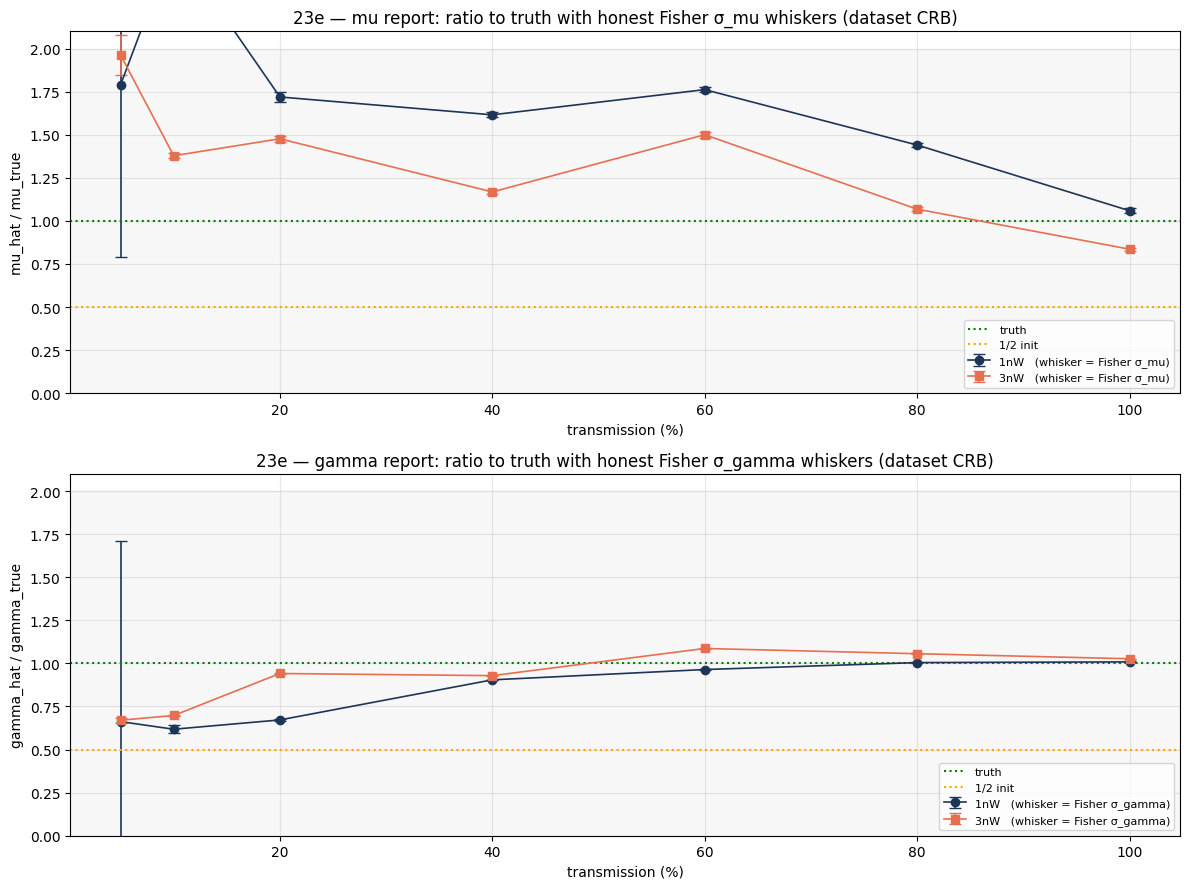

In [14]:
# ============================================================
# FIG 2 — the μ report (top) and the γ report (bottom): ratio to truth ± the Fisher CRB whisker.
#   22a's style; ONE panel per parameter, with the hue = laser power (1nW | 3nW).
#   Whisker = the dataset CRB (B): truth-inside = honesty.
# ============================================================
def _trow(power):
    return sorted([t for t in TABLE if t['exp'].startswith(power)],
                  key=lambda t: int(t['exp'].split('Trans')[-1]))

COL = {'1nW': '#1d3557', '3nW': '#e76f51'}
MK  = {'1nW': 'o-', '3nW': 's-'}
fig, axes = plt.subplots(2, 1, figsize=(12, 9))
for ax, key in zip(axes, ['mu', 'gamma']):
    for power in POWERS:
        ts = _trow(power)
        xs = [int(t['exp'].split('Trans')[-1]) for t in ts]
        if key == 'mu':
            ys  = [t['mu'] / t['mu_true'] for t in ts]
            err = [t['sig_mu_data'] / t['mu_true'] for t in ts]
        else:
            ys  = [t['gamma'] / t['gamma_true'] for t in ts]
            err = [t['sig_g_data'] / t['gamma_true'] for t in ts]
        ax.errorbar(xs, ys, yerr=err, fmt=MK[power], color=COL[power], capsize=4, ms=6, lw=1.2,
                    label=f'{power}   (whisker = Fisher σ_{key})')
    ax.axhline(1.0, color='g', ls=':', label='truth')
    ax.axhline(0.5, color='orange', ls=':', label='1/2 init')
    ax.axhspan(0.0, 2.0, color='gray', alpha=0.06)
    ax.set_xlabel('transmission (%)'); ax.set_ylabel(f'{key}_hat / {key}_true')
    ax.set_ylim(0, 2.1); ax.grid(alpha=0.3); ax.legend(fontsize=8, loc='lower right')
    ax.set_title(f'23e — {key} report: ratio to truth with honest Fisher σ_{key} whiskers (dataset CRB)')
fig.tight_layout(); plt.show()


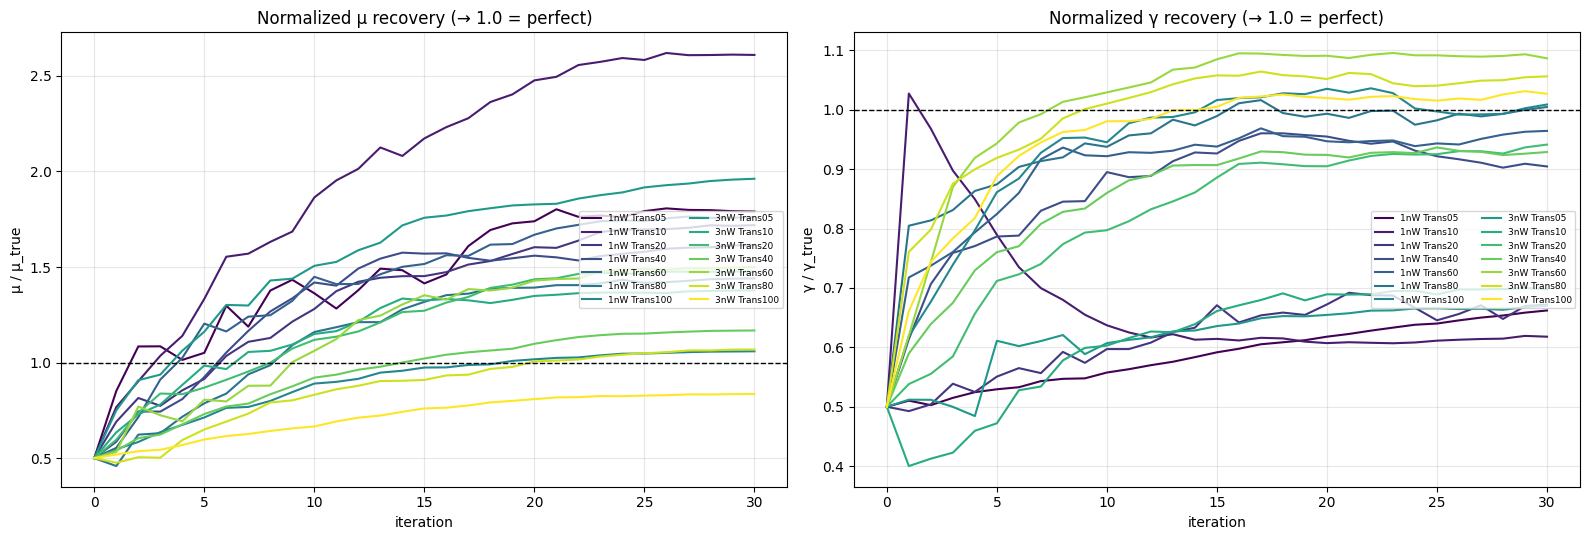

In [15]:
# ============================================================
# FIG 3 — normalized trajectories (μ/μ_true, γ/γ_true vs iteration); starts AT the 0.5x init
#   (22a verbatim)
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 5.5))
colors = plt.cm.viridis(np.linspace(0, 1, len(RESULTS)))
for r, c in zip(RESULTS, colors):
    st = [h['step'] for h in r['history']]
    axes[0].plot(st, [h['mu']    / r['mu_true']    for h in r['history']], color=c, lw=1.5, label=r['exp'])
    axes[1].plot(st, [h['gamma'] / r['gamma_true'] for h in r['history']], color=c, lw=1.5, label=r['exp'])
for ax, yl in [(axes[0], 'μ / μ_true'), (axes[1], 'γ / γ_true')]:
    ax.axhline(1.0, color='k', ls='--', lw=1); ax.set_xlabel('iteration'); ax.set_ylabel(yl); ax.grid(alpha=0.3)
    ax.legend(fontsize=6.5, ncol=2, loc='center right')
axes[0].set_title('Normalized μ recovery (→ 1.0 = perfect)')
axes[1].set_title('Normalized γ recovery (→ 1.0 = perfect)')
plt.tight_layout(); plt.show()


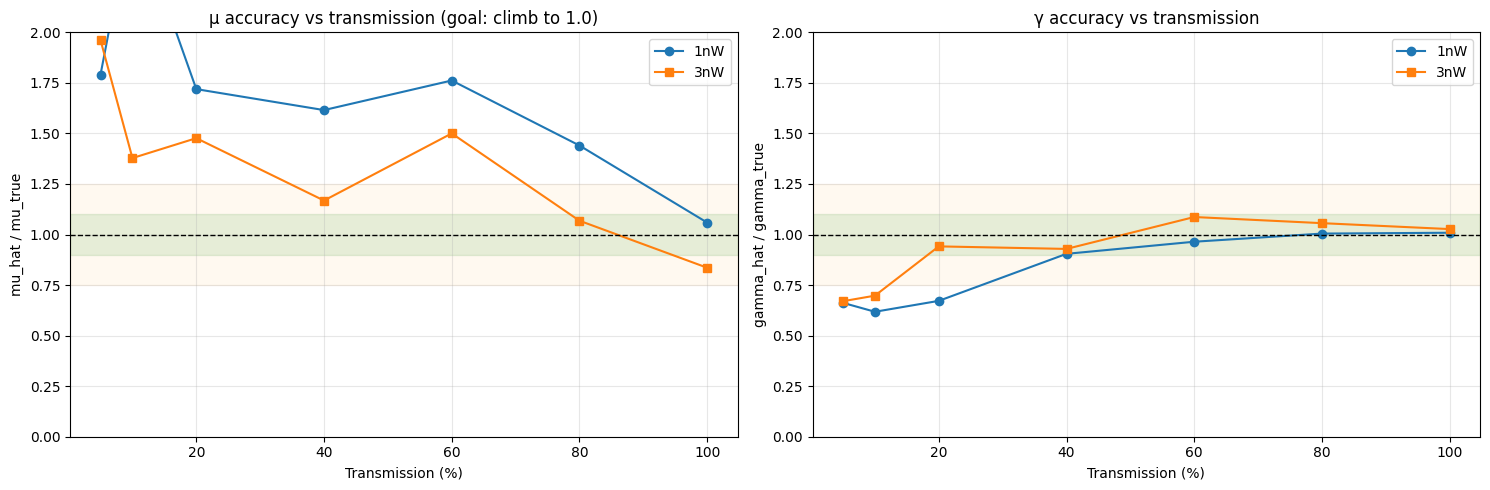

graded-goal check (ratio by transmission):
    T   mu(1nW)   mu(3nW)    g(1nW)    g(3nW)
    5     1.791     1.962     0.662      0.67
   10      2.61     1.378     0.618     0.698
   20     1.719     1.477     0.672     0.941
   40     1.615     1.168     0.905     0.929
   60     1.762       1.5     0.964     1.087
   80      1.44     1.068     1.005     1.056
  100     1.059     0.836     1.009     1.027


In [16]:
# ============================================================
# FIG 4 — accuracy vs transmission (goal: ratios climb toward 1.0 with T)   (22a verbatim)
# ============================================================
pows = ['1nW', '3nW']
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
for ax, key in zip(axes, ['mu', 'gamma']):
    for p, mk in zip(pows, ['o-', 's-']):
        rs = sorted([r for r in RESULTS if r['power'] == p], key=lambda z: z['T'])
        if not rs: continue
        xs = [r['T'] for r in rs]
        ys = [(r['mu_final']/r['mu_true']) if key == 'mu' else (r['gamma_final']/r['gamma_true']) for r in rs]
        ax.plot(xs, ys, mk, label=p, ms=6)
    ax.axhline(1.0, color='k', ls='--', lw=1)
    ax.axhspan(0.9, 1.1, color='green', alpha=0.10); ax.axhspan(0.75, 1.25, color='orange', alpha=0.06)
    ax.set_xlabel('Transmission (%)'); ax.set_ylabel(f'{key}_hat / {key}_true'); ax.set_ylim(0, 2.0)
    ax.grid(alpha=0.3); ax.legend()
axes[0].set_title('μ accuracy vs transmission (goal: climb to 1.0)')
axes[1].set_title('γ accuracy vs transmission')
plt.tight_layout(); plt.show()

print('graded-goal check (ratio by transmission):')
print(f"{'T':>5} {'mu(1nW)':>9} {'mu(3nW)':>9} {'g(1nW)':>9} {'g(3nW)':>9}")
for T in sorted({r['T'] for r in RESULTS}):
    row = [T]
    for p in pows:
        rs = [r for r in RESULTS if r['power'] == p and r['T'] == T]
        row.append(round(rs[0]['mu_final']/rs[0]['mu_true'], 3) if rs else float('nan'))
    for p in pows:
        rs = [r for r in RESULTS if r['power'] == p and r['T'] == T]
        row.append(round(rs[0]['gamma_final']/rs[0]['gamma_true'], 3) if rs else float('nan'))
    print(f"{row[0]:>5} {row[1]:>9} {row[2]:>9} {row[3]:>9} {row[4]:>9}")


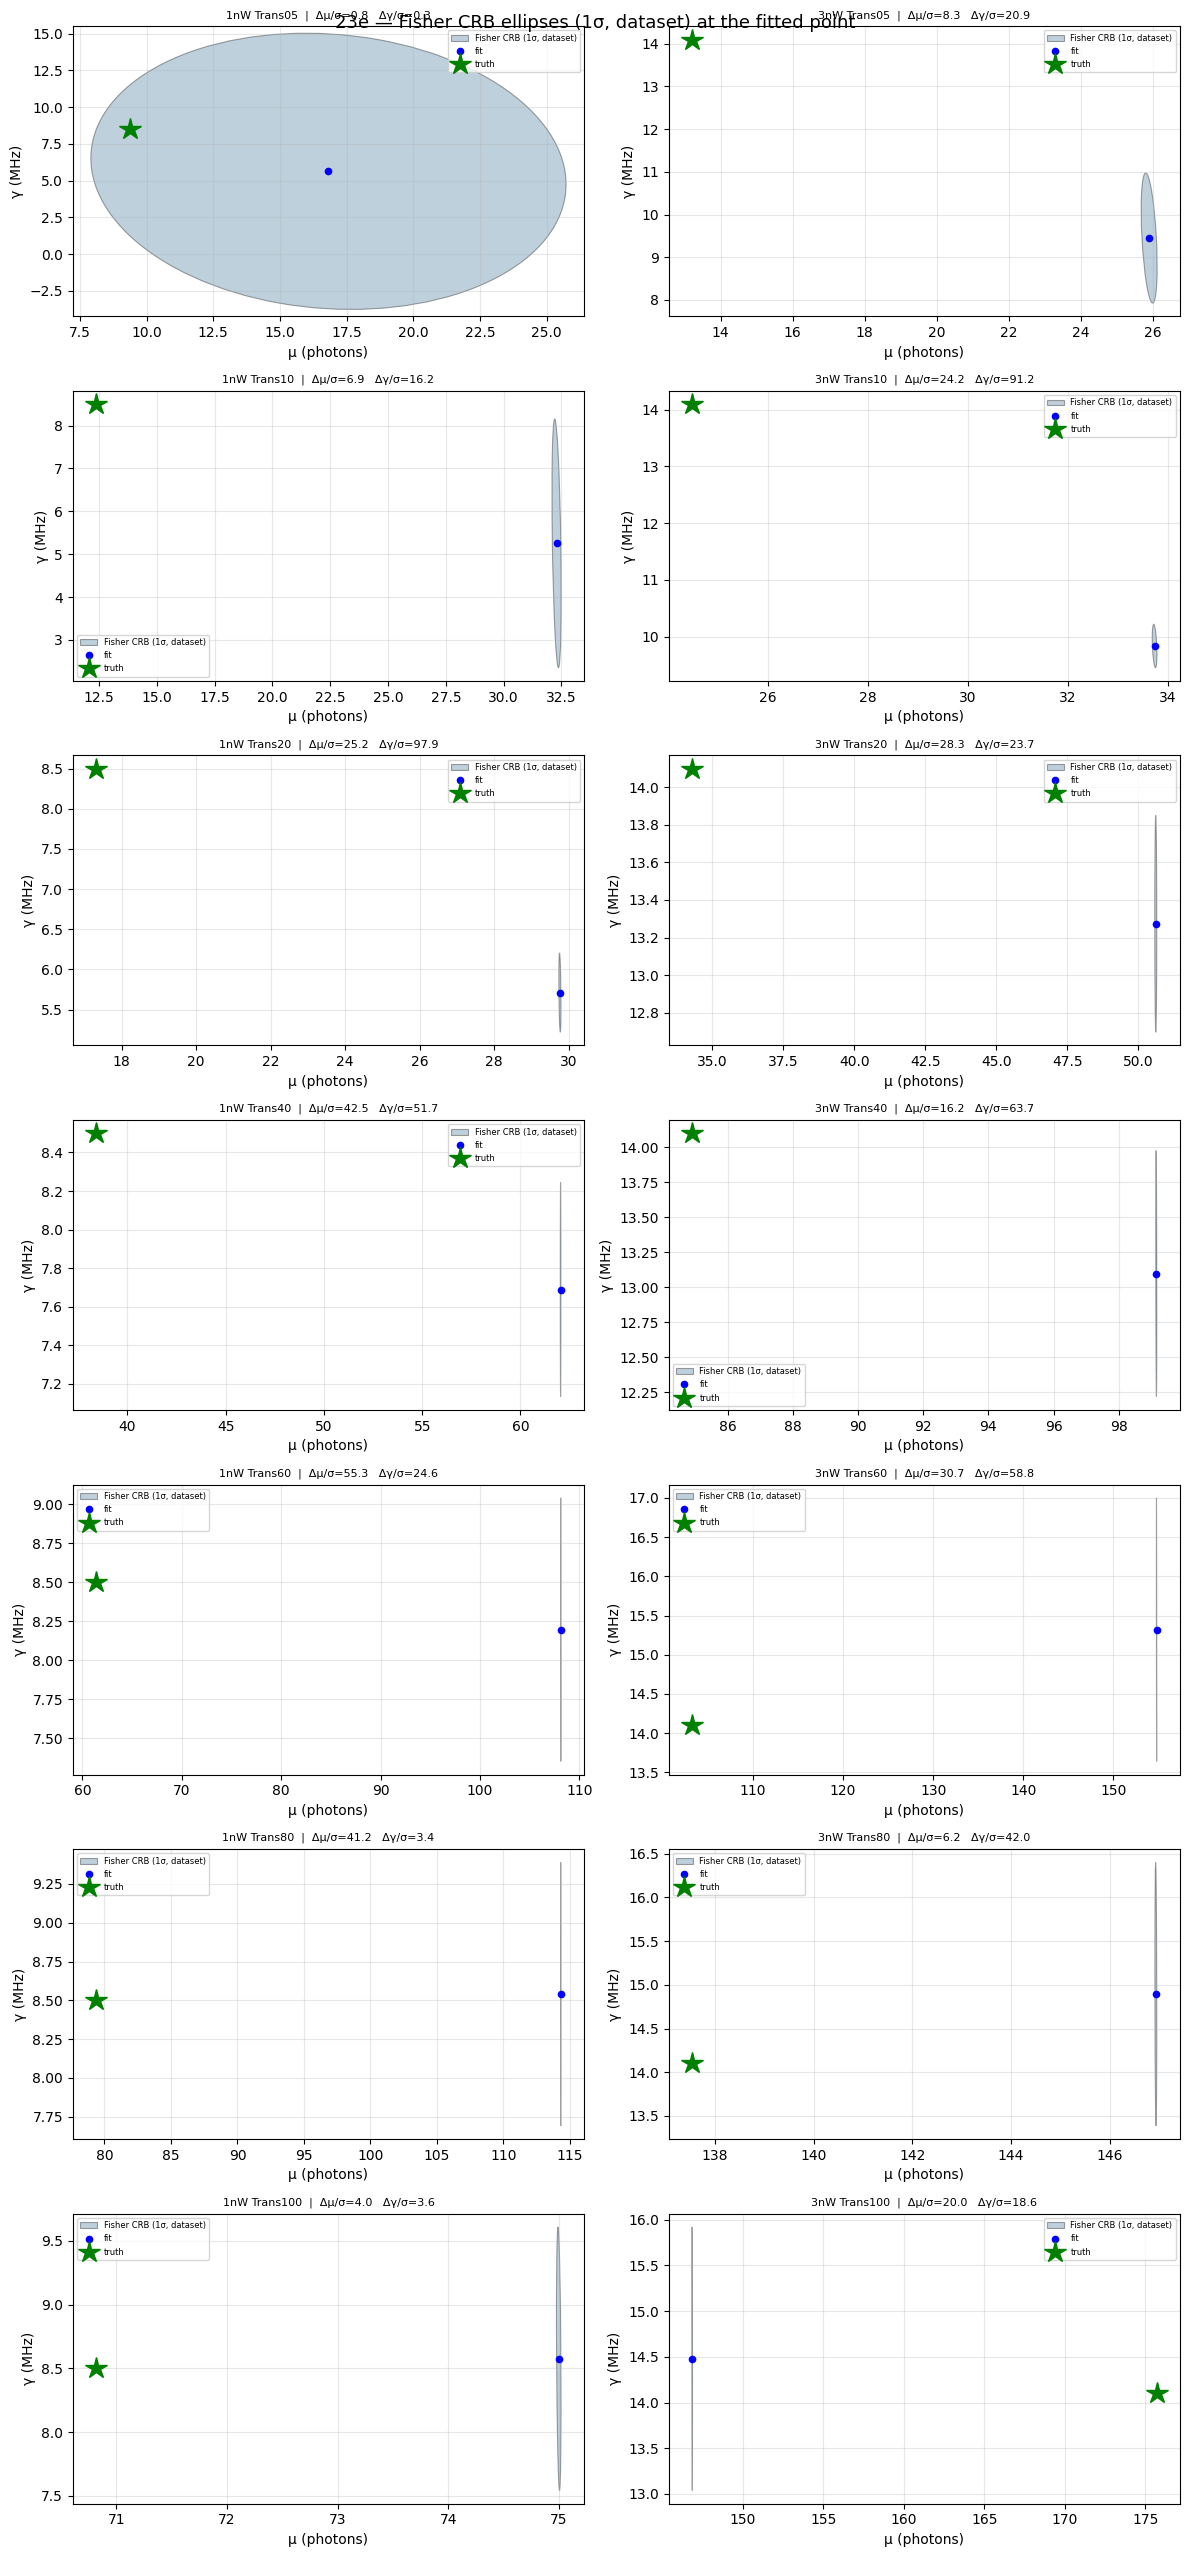

In [17]:
# ============================================================
# FIG 5 — FISHER ELLIPSES (1σ) in (μ, γ) at the fitted point
#   21c's FIG 10, laid out as 2 columns (1nW | 3nW) × 7 rows (Trans05…Trans100).
#   The ellipse is the dataset CRB (B). Variant A (per-scan) is a factor √N larger -> off-panel.
# ============================================================
from matplotlib.patches import Ellipse
fig, axes = plt.subplots(7, 2, figsize=(12, 26))
for ci, power in enumerate(POWERS):
    ts = _trow(power)
    for ri, t in enumerate(ts):
        ax = axes[ri][ci]
        sm, sg, corr = t['sig_mu_data'], t['sig_g_data'], t['corr']
        degenerate = sg < 1e-6                       # σ_γ → 0: the low-count Fisher degeneracy
        if not degenerate:
            cov = np.array([[sm**2, corr*sm*sg], [corr*sm*sg, sg**2]])
            lam_, vec = np.linalg.eigh(cov)
            ang = np.degrees(np.arctan2(vec[1, -1], vec[0, -1]))
            ax.add_patch(Ellipse((t['mu'], t['gamma']), 2*np.sqrt(lam_[0]), 2*np.sqrt(lam_[1]),
                                 angle=ang, facecolor='#457b9d', edgecolor='k', alpha=0.35, lw=0.8,
                                 label='Fisher CRB (1σ, dataset)'))
        ax.plot(t['mu'], t['gamma'], 'b.', ms=9, label='fit')
        ax.plot(t['mu_true'], t['gamma_true'], 'g*', ms=16, label='truth')
        dg_txt = 'σγ→0 (degenerate)' if degenerate else f"Δγ/σ={t['dg_sigma_data']:.1f}"
        ax.set_title(f"{t['exp']}  |  Δμ/σ={t['dmu_sigma_data']:.1f}   {dg_txt}", fontsize=8)
        ax.set_xlabel('μ (photons)'); ax.set_ylabel('γ (MHz)'); ax.grid(alpha=0.3); ax.legend(fontsize=6)
plt.suptitle('23e — Fisher CRB ellipses (1σ, dataset) at the fitted point', fontsize=13)
plt.tight_layout(); plt.show()


## Notes / caveats
- **Model: 23b's** — z-scored reward (`loglik_z`), plain Scott bandwidths, full σ channel, no γ trust
  region, no clip/clamps, `LR_GAMMA 0.5`, init 0.5×truth, 100×30 — with **ONE change**: the μ step is
  calibrated **per experiment** to a 3.3-photon step (`LR_e = TARGET_STEP/|∇μ_z|_e`) instead of 23b's single
  median-calibrated LR. Nothing changed in `src/` or in previous notebooks.
- **Likelihood**: the 2-D `(FWHM, sigma_fit)` KDE; bandwidths **fixed from the target** (rule = Scott x
  scale) -> a clean likelihood in (mu, gamma). The μ-score is the exact REINFORCE score
  (`n ~ N(mu, sigma_prop^2)`); the Fisher uses the **raw** γ chain (`GAMMA_SCALE=False`).
- **Three σ variants**: (A) the **existing per-scan** convention `J = sum_i s_i s_i^T / N`;
  (B) the **dataset CRB** `sigma/sqrt(N)`. The Scott-bandwidth variant was dropped (it conflated the
  bandwidth choice with the correction).
- **Known caveats carried in**: the target is filtered (`fit_err/FWHM < 10`) -> selection, so `N` is not
  a clean i.i.d. sample size; all `s_i` share one MC cloud (M_FINAL, averaged over FISHER_SEEDS);
  J is an **observed** (outer-product) Fisher; FM#8 means the μ-curvature comes from a mis-scaled
  σ_fit channel.
- **Figures follow 22a exactly** (same styles, same code): **FIG 1a/1b** = the interactive (μ,γ) path +
  simulated-cloud-vs-real view, one per power, with the experiment dropdown + play button + slider
  (HTML exports included); **FIG 2** = the μ report (`mu_hat/mu_true` with Fisher σ_μ whiskers) — the single
  change: **split into 1nW | 3nW**, with two whiskers per point (dataset CRB and Scott-bandwidth CRB);
  **FIG 3** = normalized trajectories; **FIG 4** = accuracy vs transmission. **FIG 5 (new)** = the 21c-style
  **Fisher CRB ellipses (1σ, dataset)** at the fitted point, laid out 2 columns (1nW | 3nW) × 7 rows
  (transparency). The report figure **FIG 2** has μ on top and γ underneath, one panel each, with the
  **hue = laser power**. Variant A (per-scan) is off-panel by design — it is √N larger. **1nW Trans05 is
  the one degenerate row** (σ_γ → 1e-13, the low-count Fisher degeneracy already flagged in 19d) — its
  ellipse is not drawn; the panel is labelled instead.
- The notebook is **cache-aware**: it loads `data/processed/23a_fisher_exp6_trial07.json` by default
  (re-render in seconds); `NB_RECOMPUTE=1` forces the full ~35 min run.
- Companion run data: `data/processed/23a_fisher_exp6_trial07.json`.